In [7]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.pso_search import ParticleSwarmLineSearch
from converters.tile.bin_1d import make_1d_bin_palette

from tests.experimental.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 9)[0]]
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]

def make_converter(params: Params):
    return ParticleSwarmLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        pop_count=10,
        generations=80,
        **params.converter_args)

Min: 0.0616 | Max: 0.2015 | Mean: 0.1318 | Std: 0.0439
Min: 0.0600 | Max: 0.2054 | Mean: 0.1380 | Std: 0.0496
Min: 0.0514 | Max: 0.2047 | Mean: 0.1344 | Std: 0.0512
Min: 0.0612 | Max: 0.2019 | Mean: 0.1343 | Std: 0.0496
Min: 0.0653 | Max: 0.1954 | Mean: 0.1332 | Std: 0.0476


C:\Users\wojte\AppData\Local\Temp\ipykernel_23236\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


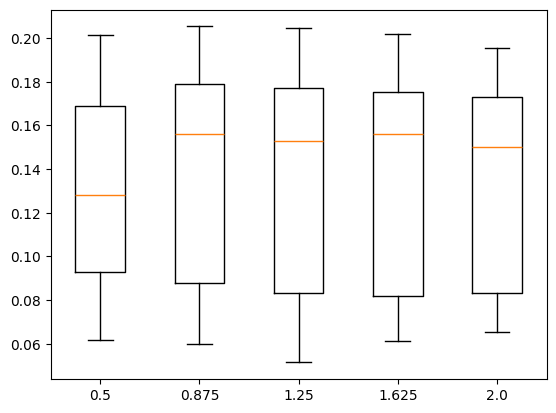

In [8]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [6]:
from PIL import Image
from converters.img_converter import ImgConverter
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = ParticleSwarmLineSearch(symbols=SYMBOLS,
                                    font=FONT,
                                    pop_count=10,
                                    generations=80)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = ImgConverter(converter).img2symbols(img, None, MAX_WIDTH, MAX_HEIGHT)
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------
 | ^DNDNNENNNDNL^DDDDD^-DN` | DNEN/DNLDENDNDNLLNDDLEED | 
 | NLLyDLLDL-DLE/LL`y`L```` | NNNNNDNDDDNN-DNNLNNLN^N/ | 
 | LNENNDDEyLLDENEDyNNyNNDN | ^LENNNNNNNDL-^NNNL/yNEDE | 
 | NNNDEE/NNLENNENNyNNNNNDL | E/NDLNNE``D/`/`ENDDNN^NN | 
 | yNNDNDN`DLNNDyNLLNENNDNE | ENNEDNDNNNyLE^`DDDNDNNND | 
 | EENNELNyN/ENENNDENNENDDE | -DNNNEDEELN``-^NNNLNEEyN | 
 | LNNDDNyNNDENNNNNDN/ENN-E | LDNDDNNNNDN`yLEN-DDENEDD | 
 | EDDEyNENNENLDNELLNNLDNEN | NNNEENNNNDD`yLL`^yENEDND | 
 | EENELNNNNNNDENNDDLNDNNDE | NNNN`NDNNN-^/DND`y``^yNN | 
---------------------------------------------------------
 | LDNDDED-/-EyDENNENEDDD`y | `-```L`/^`` | 
 | yNy^LLLNNLNDNLDL```y-`/L | LLLDLDLDLLL | 
 | DNNDDDDDLDNLDLDEL-LDN/ED | DNDNNDDNLND | 
 | EyDDDNLDNENNNNNNDDNNLNND | NDNNDN^DNDN | 
 | EE/ND^DNNDLNLNLNNNL/`EEE | NNNDDEDNEEN | 
 | NN/DDD```-DN^DNDEDL//``- | NNDD-``DNNN | 
 | EDDNNDL-LNy^L/```^-Ly`LL | NNNL-L`yNND | 
 | ^^/LD^-`ELLL/--`LNNNNNDN | NDDDDL`LNNN | 
 |